# How to extract symmetry maps from atomic resolution images

In [19]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
plt.style.use('default')
from mtflearn import ZPs

In [13]:
from mtflearn.utils import normalize_image
from skimage.transform import resize

## load an image

In [14]:
filename = 'data\\monolayer_MoSe2_80K.npy'
img = np.load(filename)[0:800, 0:800]
img = resize(img, (512, 512), order=0)
img = normalize_image(img)

In [15]:
zps = ZPs(n_max=10, size=72)
m = zps.fit_transform(img)

In [16]:
m3, m6 = m.rot_maps([3, 6])

In [17]:
mirror = m.mirror_map(m_unselect=[0,1])

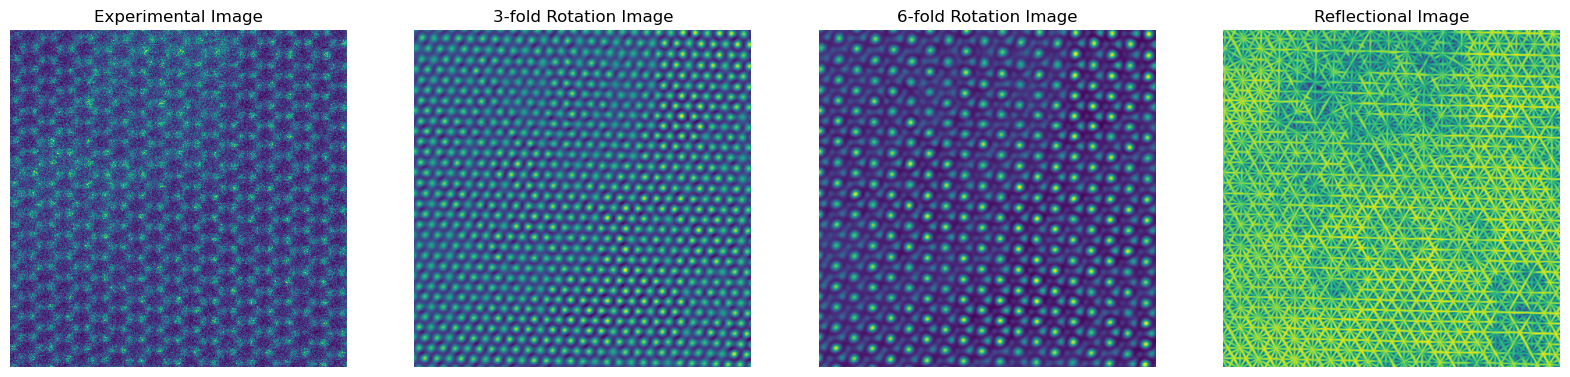

In [20]:
fig,ax = plt.subplots(1,4,figsize=(20,5),sharex=True, sharey=True)
ax[0].imshow(img[40:-40, 40:-40])
ax[0].set_title('Experimental Image')
ax[1].imshow(m3[40:-40, 40:-40])
ax[1].set_title('3-fold Rotation Image')
ax[2].imshow(m6[40:-40, 40:-40])
ax[2].set_title('6-fold Rotation Image')
ax[3].imshow(mirror[40:-40, 40:-40])
ax[3].set_title('Reflectional Image')
for i in range(4):
    ax[i].set_axis_off()

In [21]:
np.save('.\\data\\STEM img.npy',img)
np.save('.\\data\\mirror img.npy',mirror)
np.save('.\\data\\rot3 img.npy',m3)
np.save('.\\data\\rot6 img.npy',m6)